IMPORT LIBRARIES

In [320]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import numpy as np

<h1>EDA<h1>

In [321]:
path = "online_gaming_behavior_dataset.csv"
df = pd.read_csv(path)
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [322]:
df.describe()

,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


In [323]:
df.info()
df['EngagementLevel'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64

<h1>Visualization<h1>

C:\Users\rigel\AppData\Local\Temp\ipykernel_44508\1764430805.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='EngagementLevel', data=df, order=order, palette='viridis')


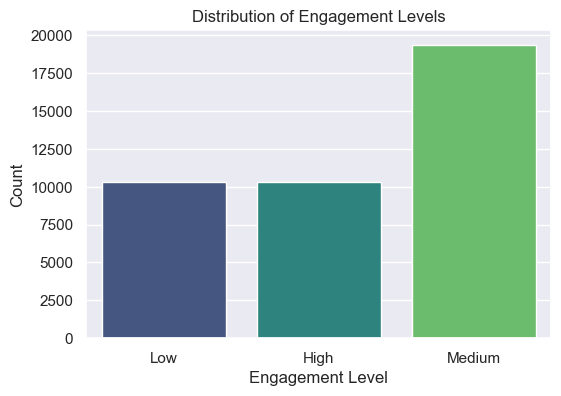

In [324]:
# Visualizzo la distribuzione di Engagement Levels
order = df['EngagementLevel'].value_counts().sort_values().index
plt.figure(figsize=(6,4))
sns.countplot(x='EngagementLevel', data=df, order=order, palette='viridis')
plt.title('Distribution of Engagement Levels')
plt.xlabel('Engagement Level')
plt.ylabel('Count')
plt.show()


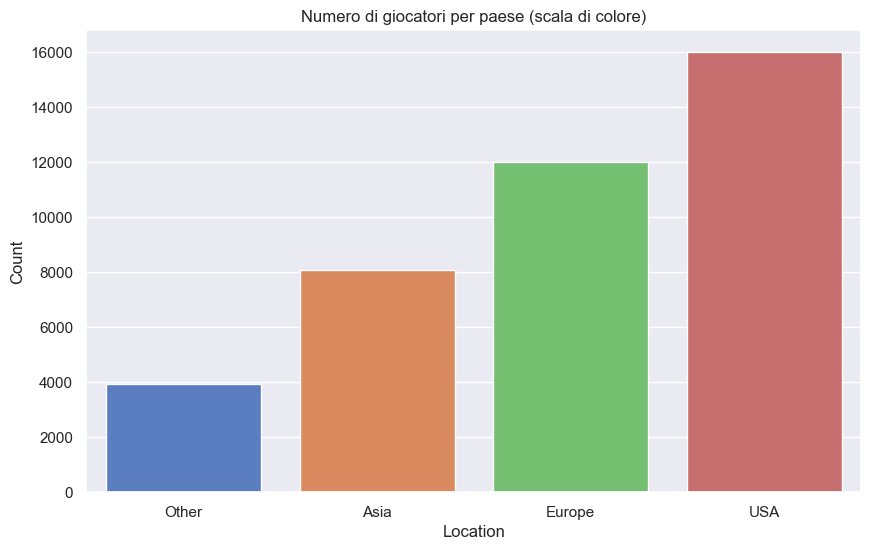

In [325]:
location = df["Location"].value_counts().reset_index()
location.columns = ['Location', 'Count']

order = df['Location'].value_counts().sort_values().index

plt.figure(figsize=(10,6))
sns.barplot(data=location, x='Location', y='Count', hue='Count', palette="muted", dodge=False, legend=False ,order=order)

plt.title("Numero di giocatori per paese (scala di colore)")
plt.show()


<Figure size 1000x600 with 0 Axes>

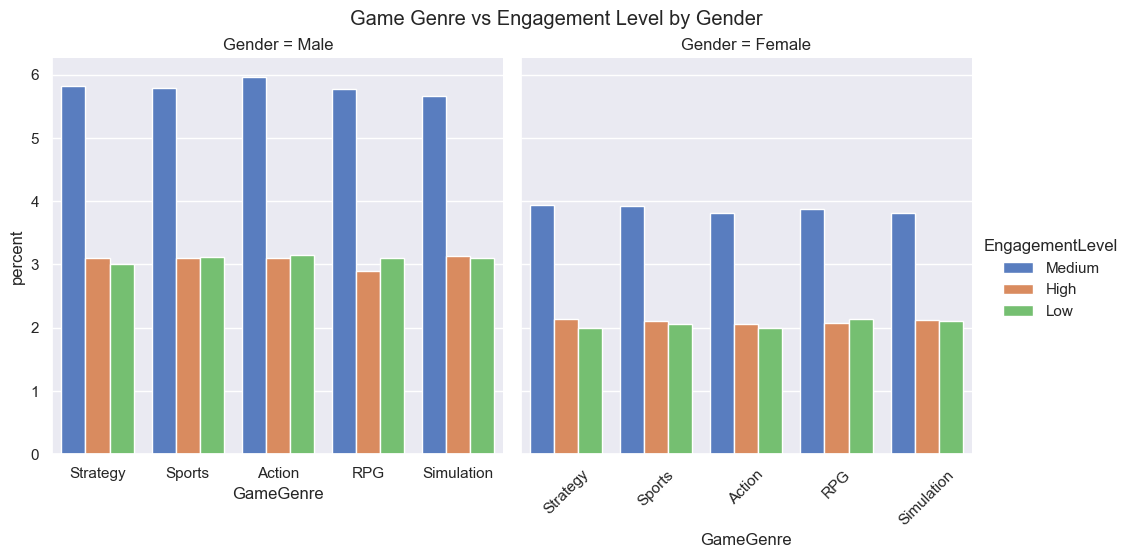

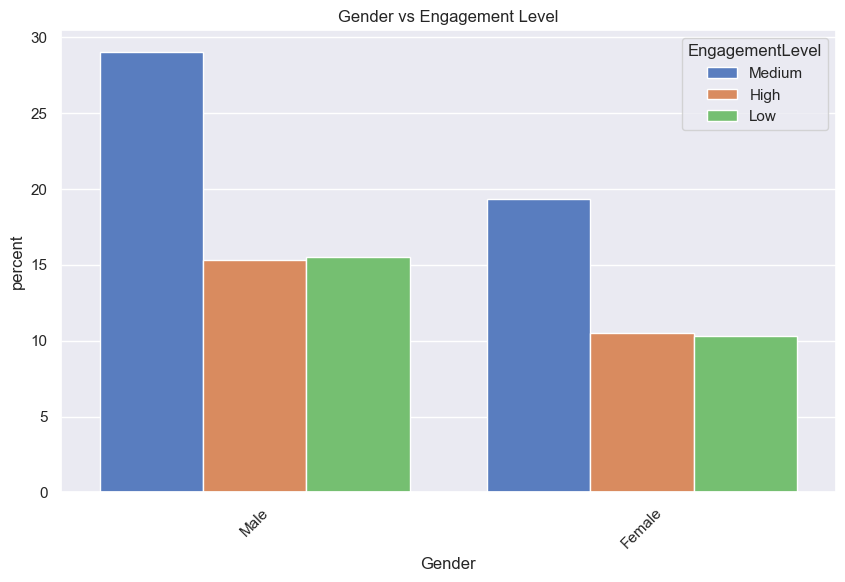

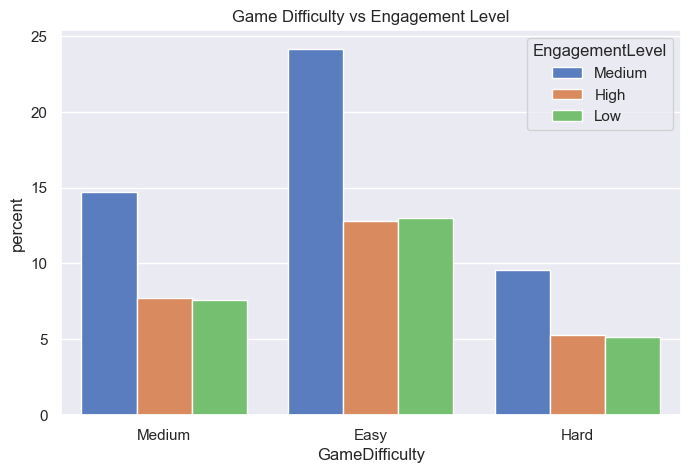

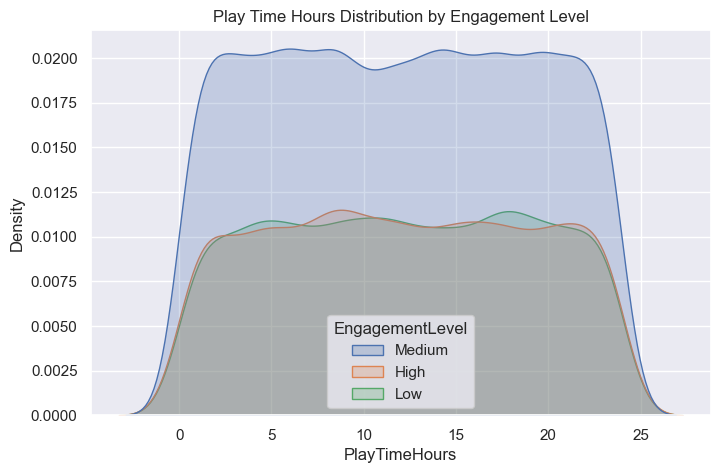

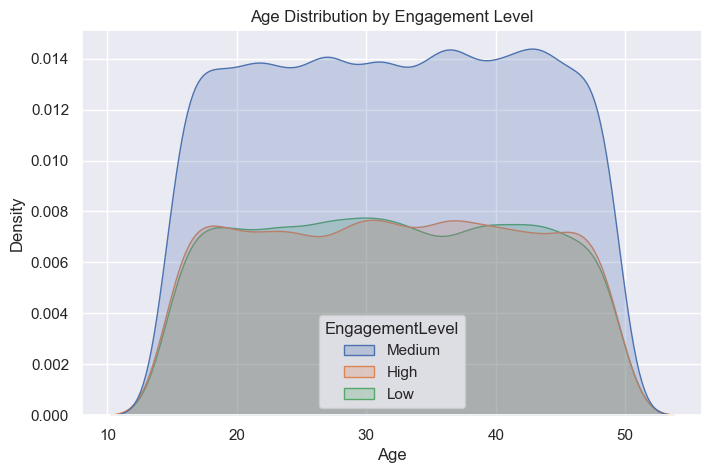

In [327]:
# Separate out Medium engagement players
medium_players = df[df['EngagementLevel'] == 'Medium']

# Compare against Low and High engagement
low_players = df[df['EngagementLevel'] == 'Low']
high_players = df[df['EngagementLevel'] == 'High']

order = df['EngagementLevel'].value_counts().sort_values().index

# Game Genre vs Engagement Level
plt.figure(figsize=(10,6))
g=sns.catplot(data=df, x='GameGenre', hue='EngagementLevel', col="Gender",kind='count', palette='muted',stat="percent")
plt.xticks(rotation=45)
g.fig.suptitle('Game Genre vs Engagement Level by Gender', y=1.02)
    

# Gender vs Engagement Level

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Gender', hue='EngagementLevel', palette='muted',stat="percent")
plt.title('Gender vs Engagement Level')
plt.xticks(rotation=45)
plt.show()

# Game Difficulty vs Engagement Level
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='GameDifficulty', hue='EngagementLevel', palette='muted',stat="percent")
plt.title('Game Difficulty vs Engagement Level')
plt.show()

# Play Time Hours Distribution by Engagement Level
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='PlayTimeHours', hue='EngagementLevel', fill=True)
plt.title('Play Time Hours Distribution by Engagement Level')
# plt.xlim(0, 100)  # limit for better focus
plt.show()

# Age Distribution by Engagement Level
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='Age', hue='EngagementLevel', fill=True)
plt.title('Age Distribution by Engagement Level')
plt.show()

In [ ]:
#copio dataframe e seleziono le colonne da convertire
df_new = df.copy()
df_drop_playerID = df.drop(columns='PlayerID', inplace=False)
obj_cols = df_new.select_dtypes(include=['object']).columns
# converto le colonne da string a  int  -- get_dummies ???
encoder = LabelEncoder()

for col in obj_cols:
    df_drop_playerID[col] = encoder.fit_transform(df_drop_playerID[col])

df_drop_playerID.head()


# encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# data_to_encode = df_drop_playerID[obj_cols]
# encoded_data = encoder.fit_transform(data_to_encode)

# encoded_df = pd.DataFrame(
#     encoded_data, 
#     columns=encoder.get_feature_names_out(obj_cols),
#     index=df_drop_playerID.index
# )

# df_final = pd.concat([df_drop_playerID.drop(columns=obj_cols), encoded_df], axis=1)

# df_final.head()

,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,AvgSessionHours
0,43,1,2,4,16.271119,0,2,6,108,79,25,2,1.800000
1,29,0,3,4,5.525961,0,2,5,144,11,10,2,2.400000
2,22,0,3,3,8.223755,0,0,16,142,35,41,0,2.366667
3,35,1,3,0,5.265351,1,0,9,85,57,47,2,1.416667
4,33,1,1,0,15.531945,0,2,2,131,95,37,2,2.183333


<Axes: >

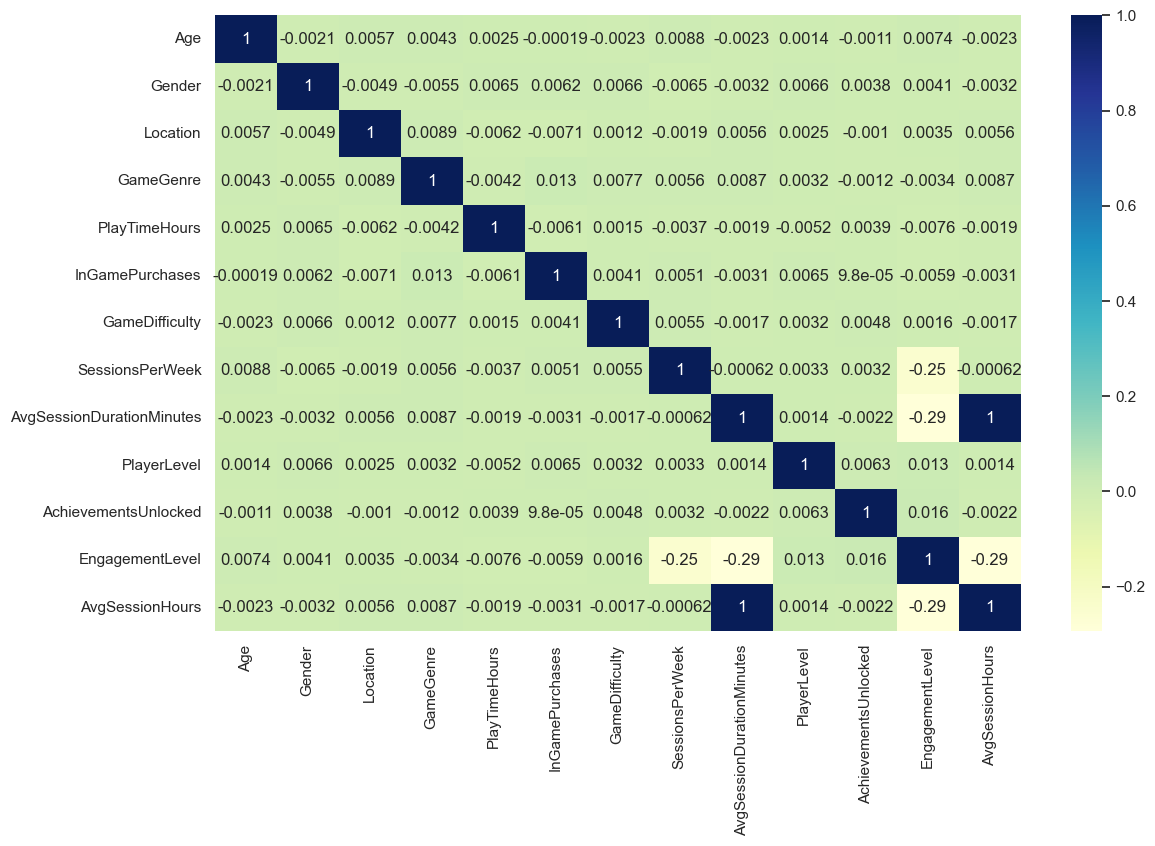

In [339]:
#visualizzo in un grafico heatmap di correlazione
sns.set_theme(rc={'figure.figsize': (13, 8)})
sns.heatmap(df_drop_playerID.corr(), annot=True, cmap='YlGnBu')

In [340]:
# df_clean = df_drop_playerID.drop(['Age','Location','Gender','GameGenre','GameDifficulty','InGamePurchases'],axis=1)
df_raw = df_drop_playerID.copy()



<h1 >feature engineering<h1>

Playtime settimanale e per sessione
Cosa sono: sono combinazioni di “quante volte si gioca” e “quanto dura ogni sessione”. L’idea è condensare frequenza e durata in indicatori più informativi del semplice valore singolo.

Interazioni: InGamePurchases × GameGenre
Cosa è: una feature d’interazione tra acquisti in-game (0/1) e il genere di gioco. L’idea è che l’effetto dell’acquisto sull’ingaggio dipenda dal genere: in alcuni generi comprare è associato a progressione/ritenzione maggiore, in altri lo è meno o in modo diverso.

Durata media in ore: è una semplice conversione da minuti in ore per aiutare la legibilità

Progressione: ratio AchievementsUnlocked per livello
Cosa è: misura l’“efficienza” con cui si sbloccano achievement rispetto al livello attuale. Formula: AchievementsUnlocked / (PlayerLevel + 1). Si aggiunge 1 per evitare divisioni per zero a livello 0.


In [341]:
# ore settimanali stimate
df_raw['WeeklyTime'] = df_raw['SessionsPerWeek']*df_raw['PlayTimeHours']

#iterazioni di Acquisto
df_raw['MonetizationByGenre'] = df_raw['InGamePurchases']*df_raw['GameGenre']

#Progressione: ratio AchievementsUnlocked per livello
df_raw["AchievementsUnlockedByLevel"] = df_raw["AchievementsUnlocked"] / (df_raw["PlayerLevel"] + 1)

df_raw["PlayerGnre"] = df_raw["PlayerLevel"] * df_raw["GameGenre"]


df_raw['PurchasesPerHour'] = df_raw['InGamePurchases'] / (df_raw['PlayTimeHours']+1)

df_raw['SessionsPerDay'] = df_raw['SessionsPerWeek'] / 7

df_raw['WeeklyInGamePurchases'] = df_raw['InGamePurchases'] / (df_raw['WeeklyTime']+1)


df_raw['LogPlayTime'] = np.log1p(df_raw['PlayTimeHours'])

df_raw['GenreLevel'] = df_raw['GameGenre'].astype(str) + '_' + df_raw['PlayerLevel'].astype(str)



#--------------------------------------------------------------------------



# df["PlayTimePerSession"] = df["PlayTimeHours"] / df["SessionsPerWeek"]
# df["PlayTimePerSession"].replace([np.inf, -np.inf], np.nan, inplace=True)
# df.fillna({'PlayTimePerSession':0}, inplace = True)


df_raw['SessionsPerAge'] = df_raw['SessionsPerWeek'] / df_raw['Age']
df_raw['EngagementIntensity'] = df_raw['SessionsPerWeek'] * df_raw['AvgSessionDurationMinutes']



df_raw.head()




,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,...,MonetizationByGenre,AchievementsUnlockedByLevel,PlayerGnre,PurchasesPerHour,SessionsPerDay,WeeklyInGamePurchases,LogPlayTime,GenreLevel,SessionsPerAge,EngagementIntensity
0,43,1,2,4,16.271119,0,2,6,108,79,...,0,0.312500,316,0.000000,0.857143,0.000000,2.849036,4_79,0.139535,648
1,29,0,3,4,5.525961,0,2,5,144,11,...,0,0.833333,44,0.000000,0.714286,0.000000,1.875788,4_11,0.172414,720
2,22,0,3,3,8.223755,0,0,16,142,35,...,0,1.138889,105,0.000000,2.285714,0.000000,2.221782,3_35,0.727273,2272
3,35,1,3,0,5.265351,1,0,9,85,57,...,0,0.810345,0,0.159608,1.285714,0.020666,1.835035,0_57,0.257143,765
4,33,1,1,0,15.531945,0,2,2,131,95,...,0,0.385417,0,0.000000,0.285714,0.000000,2.805295,0_95,0.060606,262


<h1>Cleaning<h1>

In [ ]:
df_raw.drop(['WeeklylayTime'],axis=1)

In [353]:
# df_clean = df_raw.drop(['Age','Location','Gender','GameDifficulty'],axis=1)
df_clean = df_raw.drop(['PlayTimeHours','GenreLevel','PlayerGnre','InGamePurchases','WeeklyTime'],axis=1)

<Axes: >

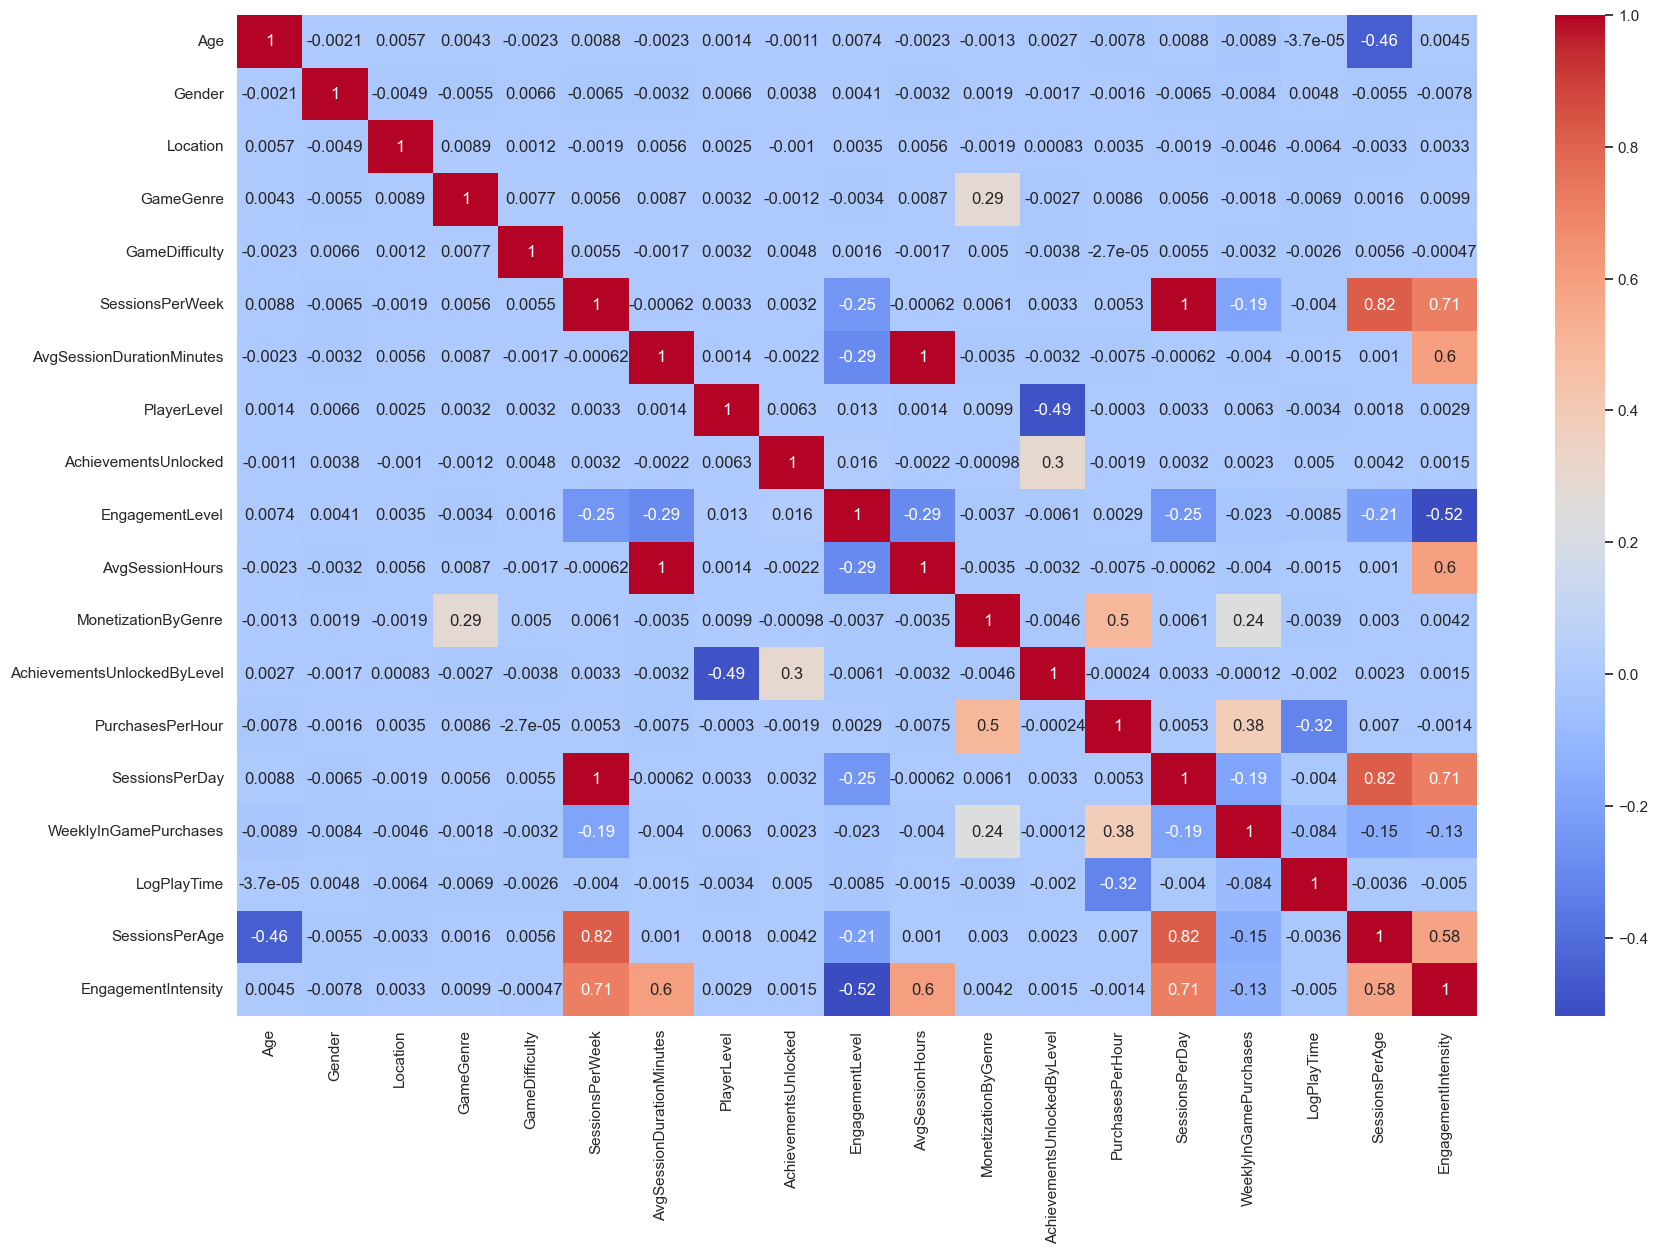

In [354]:
sns.set_theme(rc={'figure.figsize': (20, 13)})
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')

In [349]:
df_raw.drop(['InGamePurchases','WeeklyTime'],axis=1)

,Age,Gender,Location,GameGenre,PlayTimeHours,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,...,MonetizationByGenre,AchievementsUnlockedByLevel,PlayerGnre,PurchasesPerHour,SessionsPerDay,WeeklyInGamePurchases,LogPlayTime,GenreLevel,SessionsPerAge,EngagementIntensity
0,43,1,2,4,16.271119,2,6,108,79,25,...,0,0.312500,316,0.000000,0.857143,0.000000,2.849036,4_79,0.139535,648
1,29,0,3,4,5.525961,2,5,144,11,10,...,0,0.833333,44,0.000000,0.714286,0.000000,1.875788,4_11,0.172414,720
2,22,0,3,3,8.223755,0,16,142,35,41,...,0,1.138889,105,0.000000,2.285714,0.000000,2.221782,3_35,0.727273,2272
3,35,1,3,0,5.265351,0,9,85,57,47,...,0,0.810345,0,0.159608,1.285714,0.020666,1.835035,0_57,0.257143,765
4,33,1,1,0,15.531945,2,2,131,95,37,...,0,0.385417,0,0.000000,0.285714,0.000000,2.805295,0_95,0.060606,262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,32,1,3,4,20.619662,0,4,75,85,14,...,0,0.162791,340,0.000000,0.571429,0.000000,3.073603,4_85,0.125000,300
40030,44,0,2,2,13.539280,1,19,114,71,27,...,0,0.375000,142,0.000000,2.714286,0.000000,2.676854,2_71,0.431818,2166
40031,15,0,3,1,0.240057,0,10,176,29,1,...,1,0.033333,29,0.806415,1.428571,0.294068,0.215157,1_29,0.666667,1760
40032,34,1,3,3,14.017818,2,3,128,70,10,...,3,0.140845,210,0.066588,0.428571,0.023227,2.709237,3_70,0.088235,384
